# Using ROCS Scorer in DrugEx RNN

This notebook demonstrates how to use the ROCS (Rapid Overlay of Chemical Structures) scorer with DrugEx RNN for molecular generation and optimization.

## Prerequisites

To run this notebook, you need:
1. The DrugEx package installed
2. OpenEye toolkit with a valid license
3. A ROCS query file (.sq format)

## 1. Setting Up ROCS Scorer



In [1]:
from drugex.training.scorers.ez_rocs import RocsScorer
from drugex.training.scorers.fastrocs import OpenEyeScorer
import os
from rdkit.Chem import PandasTools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your ROCS query file (.sq format)
sq_file = 'model3-4_v1.sq'

# Initialize the ROCS scorer
rocs_scorer = RocsScorer(
    query_file=sq_file,                # Path to the .sq model file
    experiment_name="ccr2_experiment", # Name for temporary files
    score_type="TanimotoCombo",        # Type of score to extract (TanimotoCombo, ShapeTanimoto, or ColorTanimoto)
    use_gpu=True,
    max_isomers=4,
    max_rot_bonds=10,
    max_heavy_atoms=30,
    max_conformers=10,   # number of conformers to generate per molecule
    cpu_processes=1   # this is used when use_gpu is False
)

fastrocs_scorer = OpenEyeScorer(
    sq_model_path=sq_file,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 !!!! This can cause OOM error
    max_isomers=4,
    max_rot_bonds=10,
    max_heavy_atoms=30,
    max_conformers=10,   # same for confs
)

FastROCS GPU mode   : ON  (single process)


In [ ]:
# Run reinforcement learning (in practice, use more epochs, e.g., 30-100)
# For demonstration, we'll use just 5 epochs
explorer.fit(monitor=monitor, epochs=20, patience=10)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
training_df.head()

Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Key Parameters of RocsScorer

The `RocsScorer` class accepts several parameters to customize its behavior:

- `sq_model_path`: Path to the ROCS query file (.sq format)
- `experiment_name`: Name for temporary files created during scoring
- `score_type`: Type of score to return. Options include:
  - `"TanimotoCombo"`: Combined shape and color score (default)
  - `"ShapeTanimoto"`: Shape-only similarity score
  - `"ColorTanimoto"`: Color (chemical features) similarity score
- `use_gpu`: Whether to use GPU acceleration (default: False)
- `max_isomers`: Maximum number of isomers to enumerate per molecule (default: 4)
- `max_rot_bonds`: Maximum number of rotatable bonds to consider (default: 10)
- `max_heavy_atoms`: Maximum number of heavy atoms to process (default: 30)
- `cpu_processes`: Number of CPU processes to use if not using GPU (default: 1)

## 2. Basic Usage: Scoring Molecules

Let's score some example molecules to see how the ROCS scorer works.

In [2]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = fastrocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nROCS Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ROCS_Score': scores
})
results_df

SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ROCS Score: 0.0000

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ROCS Score: 0.4709



,SMILES,ROCS_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.000000
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.470886


In [3]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = rocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nROCS Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ROCS_Score': scores
})
results_df

SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ROCS Score: 0.3153

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ROCS Score: 0.3234



,SMILES,ROCS_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.315321
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.323386


### Visualizing the Results



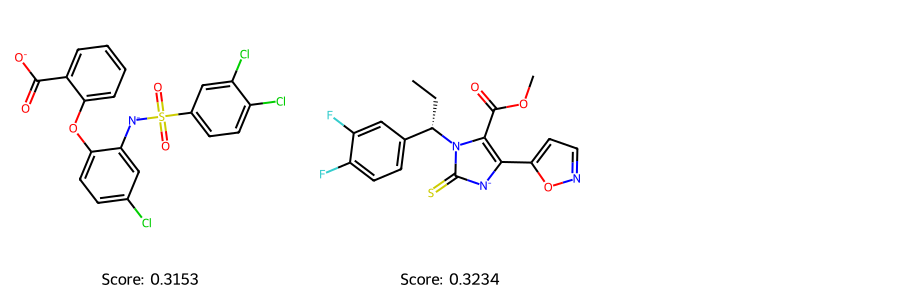

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(smi) for smi in test_smiles]

# Create labels with scores
legends = [f"Score: {score:.4f}" for score in scores]

# Display molecules with their scores
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(300, 300))
img

## 3. Integration with DrugEx RNN



In [5]:
# Import additional required modules
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor

# Path to pretrained model (adjust as needed)
GPUS = [0]  # Use GPU 0
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

# Load pretrained model
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


### Creating a Multi-Objective Environment


1. ROCS similarity (higher is better)
2. Synthetic accessibility (lower is better, using the SA score)

# Here will be needed to tweak the clipping correctly, set too low for now, 


## two types of scorers ez_rocs is a base and fastrocs is gpu optimized (with hardcoded )

In [6]:
# Create synthetic accessibility scorer
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Transform so higher is better

# Add a modifier to ROCS scorer (optional but recommended)
# This helps normalize scores and specify what values are desirable
# rocs_scorer.setModifier(SmoothClippedScore(lower_x=0.2, upper_x=0.7))

# Define scoring environment with multiple objectives
scorer_ez = [
    rocs_scorer,  # ROCS shape similarity
    sa_scorer     # Synthetic accessibility
]


scorer_fast = [
    fastrocs_scorer,  # ROCS shape similarity
    sa_scorer     # Synthetic accessibility
]

# Thresholds for considering a molecule "desirable"
thresholds = [
    0.3,  # Minimum ROCS score (after modifier)
    0.1   # Minimum SA score (after modifier)
]

# Create environment with Pareto optimization
env = DrugExEnvironment(
    scorers=scorer_fast,  # scorers_fast , scorers_ez
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()  # Multi-objective optimization scheme
)

# Finetuning

In [7]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
import multiprocessing as mp
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet


CPU_COUNT     = max(1, mp.cpu_count() - 2)  
MODEL_DIR_RL = "./rocs_rl_ccr"
if not os.path.exists(MODEL_DIR_RL):
    os.makedirs(MODEL_DIR_RL)
    
    
print(f"Fine-tuning device: {'GPU' if GPUS else 'CPU'} (GPUS: {GPUS})")

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')
data_path = "CCR_HUMAN_AL.tsv"
print(f"Loading fine-tuning data from {data_path}")
df = pd.read_csv(data_path, sep='\t')



Fine-tuning device: GPU (GPUS: [0])
Loading fine-tuning data from CCR_HUMAN_AL.tsv


In [8]:
if 'SMILES' not in df.columns:
    print(f"ERROR: No 'SMILES' column found in {data_path}")



X_train = df['SMILES'].values
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 1021
BATCH_SIZE = 64
FT_EPOCHS = 25

standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Found {len(valid_smiles)} valid SMILES strings for training")
os.makedirs(MODEL_DIR_RL, exist_ok=True)
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")
encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Found 1021 valid SMILES strings for training


In [9]:
data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

print(f"Saved vocabulary to {voc_file}")
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(
        os.path.join(MODEL_DIR_RL, f'ligand_{name}.tsv'),
        header=True, index=False, sep='\t'
    )

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'2', 'F', '=', 'EOS', 'C', 'O', '3', 'L', ')', 'c', '1', 'N', '(', 'S'} (occurrence count: 102). It will be ignored.


Saved vocabulary to ./rocs_rl_ccr/model.vocab


## Uncomment for finetuning

In [10]:
# data_set_train = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_train.tsv'), voc=voc)
# train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
# data_set_test = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_test.tsv'), voc=voc)
# valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)
# print(f"Fine-tuning model for {FT_EPOCHS} epochs")

# model.fit(train_loader, valid_loader, epochs=FT_EPOCHS,
#             monitor=FileMonitor(
#                 f"{MODEL_DIR_RL}/finetune", 
#                 save_smiles=True,
#                 reset_directory=True
#                 ))

# os.makedirs(MODEL_DIR_RL, exist_ok=True)
# model_path = f'{MODEL_DIR_RL}/finetune.pkg'
# voc.toFile(f'{MODEL_DIR_RL}/finetune.vocab')
# print(f"Model saved to {model_path}")
# print("Fine-tuning completed successfully")


### Setting Up Reinforcement Learning



In [11]:
vocab_path = f'{MODEL_DIR_RL}/finetune.vocab'
voc = VocSmiles.fromFile(vocab_path if os.path.exists(vocab_path) else
                            f'{MODEL_DIR_RL}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
finetuned.loadStatesFromFile(f'{MODEL_DIR_RL}/finetune.pkg')


In [12]:
explorer = SequenceExplorer(
    agent=finetuned,
    env=env,
    mutate=pretrained,
    epsilon=0.1,
    batch_size=256,
    n_samples=1000,
    use_gpus=GPUS
)

# Set up output directory for training logs
os.makedirs(MODEL_DIR_RL, exist_ok=True)

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,          # Save generated SMILES
    reset_directory=True       # Clear previous results
)

Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


### Training the Model


In [13]:
# Run reinforcement learning (in practice, use more epochs, e.g., 30-100)
# For demonstration, we'll use just 5 epochs
explorer.fit(monitor=monitor, epochs=20, patience=10)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
training_df.head()

Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

GPU processed 5/18 batches, avg time: 0.89s per batch
GPU processed 10/18 batches, avg time: 0.84s per batch
GPU processed 15/18 batches, avg time: 0.72s per batch


Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

GPU processed 5/18 batches, avg time: 1.42s per batch
GPU processed 10/18 batches, avg time: 1.68s per batch


GPU processed 15/18 batches, avg time: 1.35s per batch


...

GPU processed 5/7 batches, avg time: 5.20s per batch


Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

GPU processed 5/9 batches, avg time: 12.46s per batch


Calculating policy gradient...:   0%|          | 0/4 [00:00<?, ?it/s]

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.90,0.85,0.02,0.469,0.044,0.024,1
1,2,0.88,0.84,0.12,0.496,0.141,0.032,2
2,3,0.85,0.85,0.24,0.546,0.285,0.057,3
3,4,0.88,0.86,0.25,0.580,0.366,0.069,4
4,5,0.93,0.93,0.20,0.575,0.372,0.175,4


Generating molecules:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 100 molecules
Desirable molecules: 37 (37.0%)
Average ROCS score: 0.2651
Average SA score: 0.9620


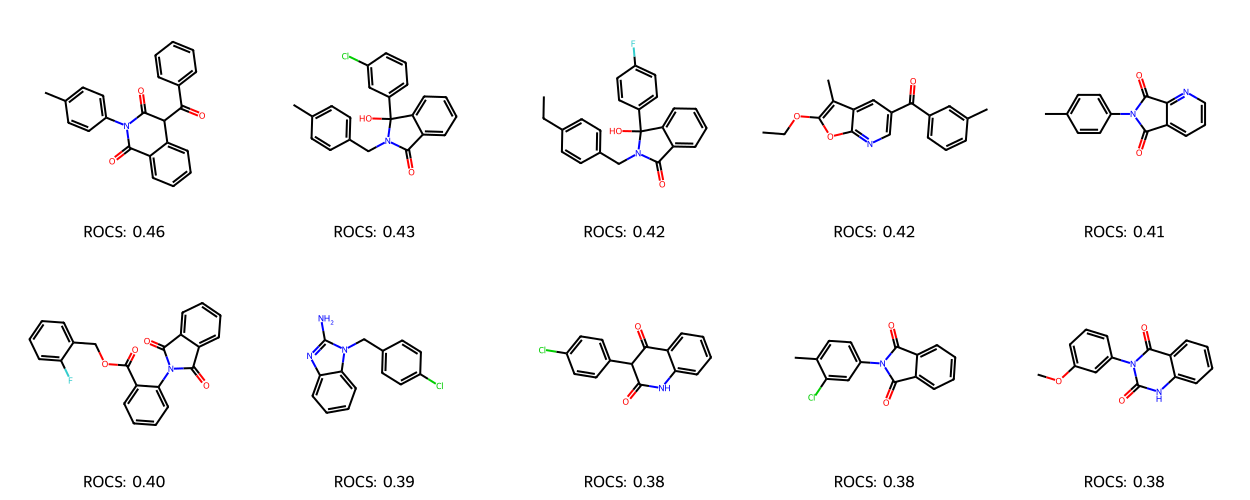

In [14]:
# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

# Generate molecules
generated = optimized_model.generate(num_samples=100)
generated_smiles = generated.SMILES.tolist()

# Score the generated molecules
scores = env.getScores(generated_smiles)
scores_df = pd.DataFrame(scores)

# Display summary statistics
print(f"Generated {len(generated_smiles)} molecules")
print(f"Desirable molecules: {scores_df['Desired'].sum()} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"Average SA score: {scores_df['SA'].mean():.4f}")

# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img




Some key steps were:

1. Setting up the ROCS scorer with an appropriate shape query (.sq file)
2. Scoring molecules to evaluate their 3D shape similarity
3. Integrating the scorer into a DrugEx reinforcement learning pipeline
4. Training a model to generate molecules with high shape similarity
5. Evaluating the results and considering performance optimizations



### GPU vs. CPU Performance

The `RocsScorer` supports GPU acceleration, which can significantly improve performance. Let's compare GPU and CPU performance for a small batch of molecules.